# CAPSTONE PRJECT ADUIN

#### Pertanyaan Bisnis
- Kategori apa yang paling banyak diadukan?
- Kategori apa yang paling banyak memiliki urgensi **Tinggi**?
- Berdasarkan data pengaduan, apakah pengaduan dengan urgensi Tinggi selalu disertai dengan sentimen Negatif? Jika tidak, seberapa besar proporsi urgensi Tinggi yang bersentimen Netral atau Positif?

### Impor Library yang Dibutuhkan

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Load df

In [3]:
# ID unik file link Google Drive
file_id = '1d1Qio6ir73Qhqfa8N3ulDxpzErmrZX_n'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Membaca data
df = pd.read_csv(url)
df.head()

,sumber,tanggal,teks_bersih,urgensi,sentimen,kategori_infrastruktur,kategori_lingkungan,kategori_air_sanitasi,kategori_bencana,kategori_transportasi,kategori_pelayanan_publik,kategori_ekonomi,kategori_keamanan,kategori_pendidikan,kategori_kesehatan
0,berita_kaggle,2026-03-26,tempo co jakarta gubernur jakarta pramono anun...,Rendah,Positif,0,0,1,0,0,0,0,0,0,0
1,berita_kaggle,2024-09-12,warga rt 05 rw 01 duri kosambi cengkareng jaka...,Tinggi,Netral,0,0,1,0,0,0,0,0,0,0
2,berita_kaggle,2026-03-26,calon gubernur cagub jakarta pramono anung ber...,Sedang,Negatif,0,0,1,0,0,0,0,0,0,0
3,berita_kaggle,2026-03-26,alat berat menyelesaikan proyek normalisasi su...,Rendah,Netral,0,1,1,0,0,0,0,0,0,0
4,berita_kaggle,2026-03-26,pemerintah kabupaten bangli bali meminta resto...,Rendah,Netral,0,0,0,0,0,1,0,0,0,0


## Exploratory Data Analysis




#### Eksplorasi Data

In [6]:
df.describe(include="all")

,sumber,tanggal,teks_bersih,urgensi,sentimen,kategori_infrastruktur,kategori_lingkungan,kategori_air_sanitasi,kategori_bencana,kategori_transportasi,kategori_pelayanan_publik,kategori_ekonomi,kategori_keamanan,kategori_pendidikan,kategori_kesehatan
count,6083,6083,6083,6083,6083,6083.000000,6083.000000,6083.000000,6083.000000,6083.000000,6083.000000,6083.000000,6083.000000,6083.000000,6083.000000
unique,2,128,5805,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,berita_kaggle,2026-03-26,phk channel live,Rendah,Netral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4835,4420,6,3716,4849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.116554,0.168009,0.086799,0.081046,0.136775,0.131843,0.180996,0.131843,0.095512,0.089594
std,NaN,NaN,NaN,NaN,NaN,0.320915,0.373905,0.281564,0.272927,0.343638,0.338348,0.385047,0.338348,0.293945,0.285623
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
# Cek missing value
df.isnull().sum()

,0
sumber,0
tanggal,0
teks_bersih,0
urgensi,0
sentimen,0
kategori_infrastruktur,0
kategori_lingkungan,0
kategori_air_sanitasi,0
kategori_bencana,0
kategori_transportasi,0


In [10]:
# Cek data duplikat
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
6078,False
6079,False
6080,False
6081,False


Insight:
* Tidak ditemukan data missing value pada dataset
* Tidak ditemukan data duplikat pada dataset
* Baris pada dataset berjumlah 6083 dan tidak bertipe data numerik



#### Analisis Univariate

In [11]:
# Setup tema
sns.set_theme(style="whitegrid", palette="muted")

In [13]:
# Bar chart vertikal
def plot_bar_v(series, title, ax, color=None):
    counts = series.value_counts()
    ax.bar(counts.index, counts.values, color=color, width=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Jumlah")
    for patch in ax.patches:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 20,
            f"{int(patch.get_height()):,}",
            ha="center", fontsize=10
        )
    ax.spines[["top", "right"]].set_visible(False)

# Bar chart horizontal
def plot_bar_h(series, title, ax):
    series_sorted = series.sort_values(ascending=True)
    ax.barh(series_sorted.index, series_sorted.values)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Jumlah")
    for patch in ax.patches:
        ax.text(
            patch.get_width() + 10,
            patch.get_y() + patch.get_height() / 2,
            f"{int(patch.get_width()):,}",
            va="center", fontsize=9
        )
    ax.spines[["top", "right"]].set_visible(False)

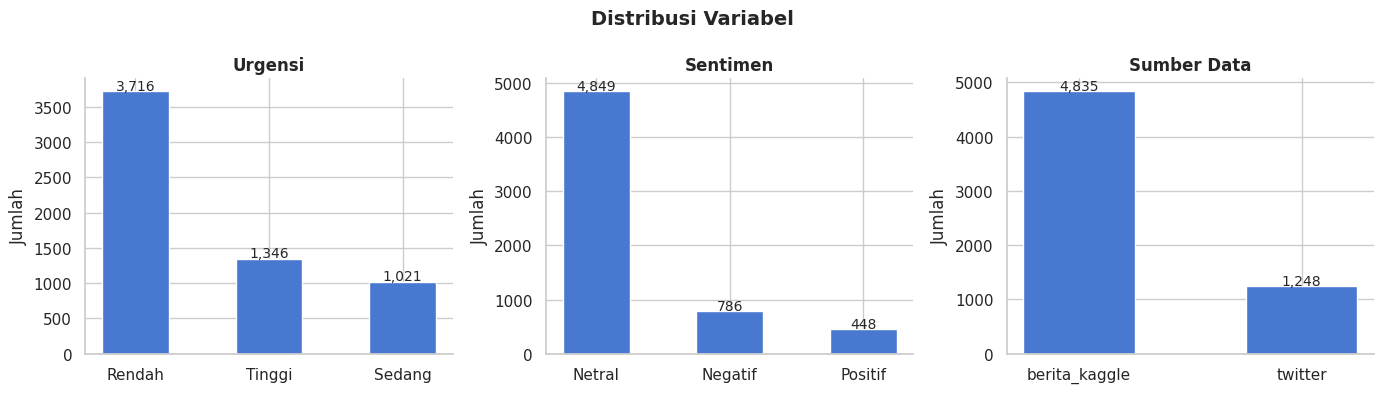

In [16]:
# Bar Chart Distribusi Variabel
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))
fig.suptitle("Distribusi Variabel", fontsize=14, fontweight="bold")

plot_bar_v(df["urgensi"],  "Urgensi",     axes[0])
plot_bar_v(df["sentimen"], "Sentimen",    axes[1])
plot_bar_v(df["sumber"],   "Sumber Data", axes[2])

fig.tight_layout()
plt.show()

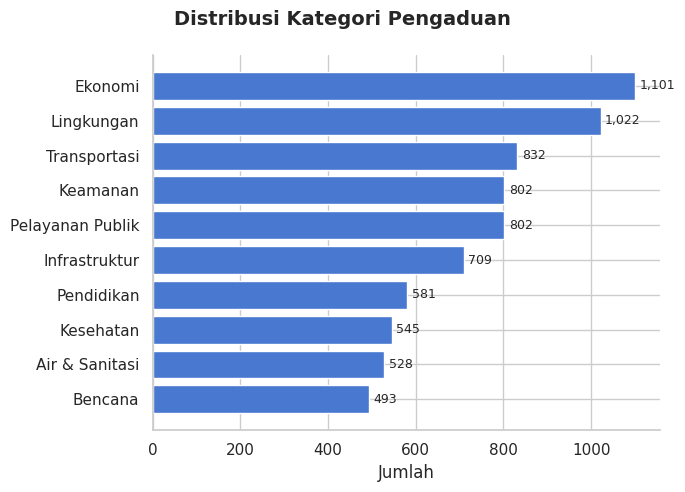

In [17]:
# Distribusi Kategori
kategori_cols = [c for c in df.columns if c.startswith("kategori_")]

label_map = {
    "kategori_infrastruktur":    "Infrastruktur",
    "kategori_lingkungan":       "Lingkungan",
    "kategori_air_sanitasi":     "Air & Sanitasi",
    "kategori_bencana":          "Bencana",
    "kategori_transportasi":     "Transportasi",
    "kategori_pelayanan_publik": "Pelayanan Publik",
    "kategori_ekonomi":          "Ekonomi",
    "kategori_keamanan":         "Keamanan",
    "kategori_pendidikan":       "Pendidikan",
    "kategori_kesehatan":        "Kesehatan",
}

kategori_count = df[kategori_cols].sum().rename(label_map)

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("Distribusi Kategori Pengaduan", fontsize=14, fontweight="bold")

plot_bar_h(kategori_count, "", ax)

fig.tight_layout()
plt.show()

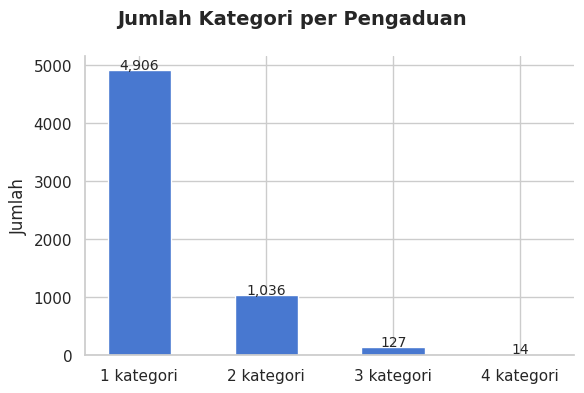

jumlah_kategori
1    4906
2    1036
3     127
4      14
Name: count, dtype: int64


In [19]:
# Jumlah Kategori per Aduan
df["jumlah_kategori"] = df[kategori_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle("Jumlah Kategori per Pengaduan", fontsize=14, fontweight="bold")

plot_bar_v(
    df["jumlah_kategori"].astype(str).map(lambda x: f"{x} kategori"),
    "", ax
)

fig.tight_layout()
plt.show()

print(df["jumlah_kategori"].value_counts().sort_index())

Insight:
* Urgensi
  - Keluhan dengan urgensi Rendah mendominasi (3.716) dibandingkan urgensi tinggi dan sedang
  - Distribusi tidak seimbang. Perlu melakukan sesuatu untuk mengatasi ini karena akan sangat memengaruhi pelatihan model klasifikasinya

* Sentimen
  - Sentimen Netral mendominasi dibandingkan sentimen Positif atau Negatif
  - Distribusi tidak seimbang. Apakah ada kemungkinan model sentimennya terlalu konservatif dalam melabeli Negatif?

* Sumber Data
  - berita_kaggle lebih banyak dibandingkan data dari twitter

* Kategori
  - Kategori Ekonomi terbanyak (1.101), disusul kategori Lingkungan (1.022)
  - Kategori Bencana (493) dan Kesehatan (545) paling sedikit dikeluhkan
  - Sebagian besar data (4.906 baris atau 80.6%) hanya punya 1 kategori per pengaduan, sisanya 2–4 kategori


#### Analisis Bivariat dan Multivariat

In [26]:
# Crosstab jumlah
ct_jumlah = pd.crosstab(df["urgensi"], df["sentimen"])

# Crosstab persentase (per baris)
ct_persen = ct_jumlah.div(ct_jumlah.sum(axis=1), axis=0).mul(100).round(1)

print("Crosstab Urgensi × Sentimen (Jumlah)")
print(ct_jumlah)
print ("\n")
print("Crosstab Urgensi × Sentimen (% per Urgensi)")
print(ct_persen)

Crosstab Urgensi × Sentimen (Jumlah)
sentimen  Negatif  Netral  Positif
urgensi                           
Rendah        286    3136      294
Sedang        347     616       58
Tinggi        153    1097       96


Crosstab Urgensi × Sentimen (% per Urgensi)
sentimen  Negatif  Netral  Positif
urgensi                           
Rendah        7.7    84.4      7.9
Sedang       34.0    60.3      5.7
Tinggi       11.4    81.5      7.1


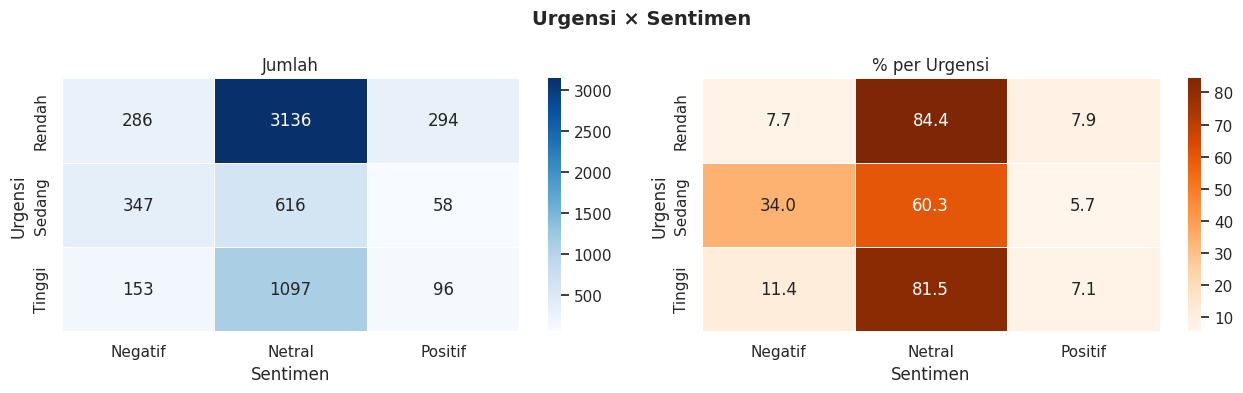

In [27]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 4))
fig.suptitle("Urgensi × Sentimen", fontsize=14, fontweight="bold")

sns.heatmap(
    ct_jumlah,
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title("Jumlah")
axes[0].set_xlabel("Sentimen")
axes[0].set_ylabel("Urgensi")

sns.heatmap(
    ct_persen,
    annot=True, fmt=".1f", cmap="Oranges",
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title("% per Urgensi")
axes[1].set_xlabel("Sentimen")
axes[1].set_ylabel("Urgensi")

fig.tight_layout()
plt.show()

In [28]:
# Untuk setiap kategori, hitung berapa banyak yang Tinggi / Sedang / Rendah
rows = []
for col, label in label_map.items():
    subset = df[df[col] == 1]["urgensi"].value_counts()
    subset.name = label
    rows.append(subset)

kategori_urgensi = pd.DataFrame(rows).fillna(0).astype(int)
kategori_urgensi = kategori_urgensi[["Tinggi", "Sedang", "Rendah"]]

print("=== Kategori × Urgensi ===")
print(kategori_urgensi)

=== Kategori × Urgensi ===
urgensi           Tinggi  Sedang  Rendah
Infrastruktur        132     241     336
Lingkungan           249     182     591
Air & Sanitasi       117      85     326
Bencana              396      14      83
Transportasi         159     212     461
Pelayanan Publik     193      95     514
Ekonomi              107     161     833
Keamanan             122      82     598
Pendidikan           140      90     351
Kesehatan            111      97     337


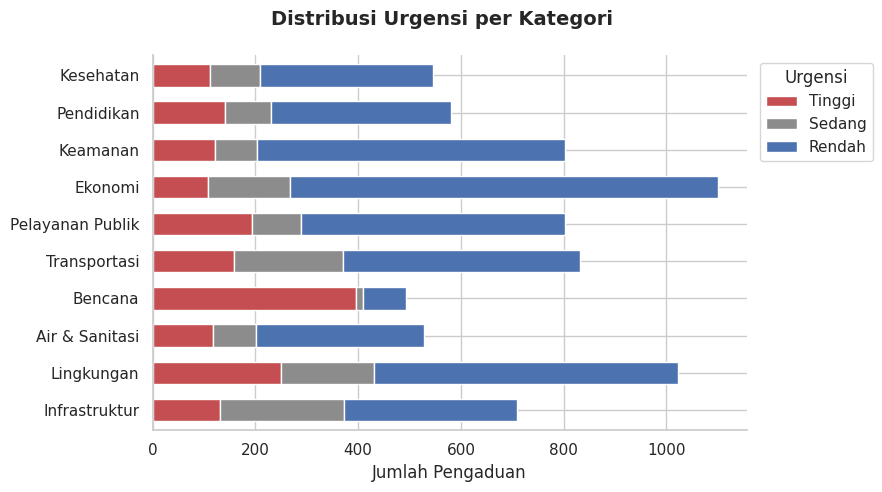

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Distribusi Urgensi per Kategori", fontsize=14, fontweight="bold")

kategori_urgensi.plot(
    kind="barh", stacked=True,
    color=["#C44E52", "#8C8C8C", "#4C72B0"],
    ax=ax, width=0.6
)

ax.set_xlabel("Jumlah Pengaduan")
ax.set_ylabel("")
ax.legend(title="Urgensi", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [30]:
rows = []
for col, label in label_map.items():
    subset = df[df[col] == 1]["sentimen"].value_counts()
    subset.name = label
    rows.append(subset)

kategori_sentimen = pd.DataFrame(rows).fillna(0).astype(int)
kategori_sentimen = kategori_sentimen[["Negatif", "Netral", "Positif"]]

print("=== Kategori × Sentimen ===")
print(kategori_sentimen)

=== Kategori × Sentimen ===
sentimen          Negatif  Netral  Positif
Infrastruktur         218     449       42
Lingkungan            149     803       70
Air & Sanitasi         46     444       38
Bencana                33     429       31
Transportasi           75     695       62
Pelayanan Publik      212     537       53
Ekonomi                77     933       91
Keamanan               48     689       65
Pendidikan             76     459       46
Kesehatan              61     434       50


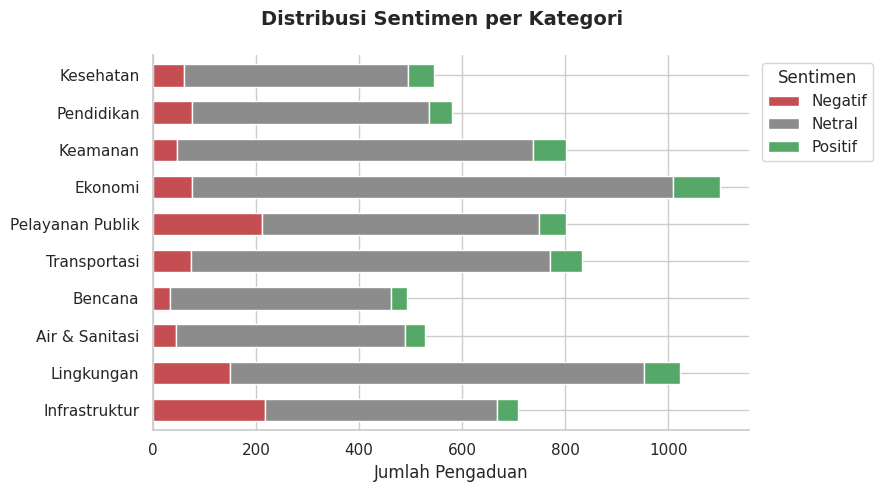

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Distribusi Sentimen per Kategori", fontsize=14, fontweight="bold")

kategori_sentimen.plot(
    kind="barh", stacked=True,
    color=["#C44E52", "#8C8C8C", "#55A868"],
    ax=ax, width=0.6
)

ax.set_xlabel("Jumlah Pengaduan")
ax.set_ylabel("")
ax.legend(title="Sentimen", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

Insight:
* Urgensi × Sentimen (heatmap)
  - Pengaduan urgensi Tinggi ternyata didominasi sentimen Netral (81.5%), bukan Negatif seperti yang mungkin diasumsikan. Artinya, tingginya urgensi tidak selalu diekspresikan dengan bahasa yang emosional/negatif
  - Urgensi Sedang memiliki proporsi sentimen Negatif tertinggi
  - Urgensi Rendah memiliki sentimen 84.4% Netral, Negatif dan Positif hampir seimbang (7.7% vs 7.9%)

* Distribusi Urgensi per Kategori
  - Bencana merupakan kategori dengan proporsi urgensi Tinggi paling besar relatif terhadap totalnya
  - Lingkungan dan Ekonomi jumlah pengaduannya banyak, tetapi tidak mendapatkan urgensi Tinggi
  - Transportasi punya distribusi urgensi yang cukup merata antara Tinggi, Sedang, dan Rendah

* Distribusi Sentimen per Kategori
  - Infrastruktur dan Pelayanan Publik punya porsi Negatif paling besar dibanding kategori lain
  - Bencana hampir seluruhnya Netral, kemungkinan karena ditulis dalam gaya pelaporan, bukan ekspresi emosi (kesenjangan sumber data)
  - Ekonomi punya porsi Positif paling besar, mungkin ada berita positif tentang ekonomi yang masuk ke dataset

#### Cek Outlier

In [32]:
kategori_cols = [c for c in df.columns if c.startswith("kategori_")]

df["jumlah_kategori"] = df[kategori_cols].sum(axis=1)

no_kategori = df[df["jumlah_kategori"] == 0]

print(f"Baris tanpa kategori apapun: {len(no_kategori)}")

Baris tanpa kategori apapun: 0


In [42]:
# Urgensi Tinggi tapi Positif
tinggi_positif = df[(df["urgensi"] == "Tinggi") & (df["sentimen"] == "Positif")]

print(f"Urgensi Tinggi + Sentimen Positif: {len(tinggi_positif)}")
print("\nContoh teksnya:")
print(tinggi_positif["teks_bersih"].head(3).to_string())

Urgensi Tinggi + Sentimen Positif: 96

Contoh teksnya:
99     perusahaan gas negara pgn memastikan aliran ga...
162    info nasional badan amil zakat nasional baznas...
230    komandan regu satgas penanggulangan bencana bp...


In [43]:
# Cek apakah ada nilai selain yang seharusnya
valid_urgensi  = {"Tinggi", "Sedang", "Rendah"}
valid_sentimen = {"Positif", "Netral", "Negatif"}
valid_sumber   = {"berita_kaggle", "twitter"}

invalid_urgensi  = df[~df["urgensi"].isin(valid_urgensi)]
invalid_sentimen = df[~df["sentimen"].isin(valid_sentimen)]
invalid_sumber   = df[~df["sumber"].isin(valid_sumber)]

print(f"Nilai tidak valid di urgensi  : {len(invalid_urgensi)}")
print(f"Nilai tidak valid di sentimen : {len(invalid_sentimen)}")
print(f"Nilai tidak valid di sumber   : {len(invalid_sumber)}")

Nilai tidak valid di urgensi  : 0
Nilai tidak valid di sentimen : 0
Nilai tidak valid di sumber   : 0


In [45]:
# Kolom kategori seharusnya hanya berisi 0 atau 1
for col in kategori_cols:
    nilai_unik = df[col].unique()
    if not set(nilai_unik).issubset({0, 1}):
        print(f"Anomali di {col}: {nilai_unik}")

print("Seluruh kolom kategori hanya berisi 0 dan 1."
      if all(set(df[col].unique()).issubset({0, 1}) for col in kategori_cols)
      else "")

Seluruh kolom kategori hanya berisi 0 dan 1.


In [46]:
df["panjang_teks"] = df["teks_bersih"].str.split().str.len()

print("=== Statistik Panjang Teks ===")
print(df["panjang_teks"].describe())

# Teks yang sangat pendek (kurang dari 5 kata)
teks_pendek = df[df["panjang_teks"] < 5]
print(f"\nTeks kurang dari 5 kata: {len(teks_pendek)}")
if len(teks_pendek) > 0:
    print(teks_pendek[["teks_bersih", "panjang_teks"]].head(5))

=== Statistik Panjang Teks ===
count    6083.000000
mean       44.086470
std        13.044926
min         2.000000
25%        50.000000
50%        50.000000
75%        50.000000
max        50.000000
Name: panjang_teks, dtype: float64

Teks kurang dari 5 kata: 46
                teks_bersih  panjang_teks
4940    banjir anying cadas             3
4962        banjir ya allah             3
4980    oleh jenofli banjir             3
5019  amagaican dad phk phk             4
5052    phk vanessa myrinna             3


In [47]:
print("=== Sumber teks kurang dari 5 kata ===")
print(teks_pendek["sumber"].value_counts())

=== Sumber teks kurang dari 5 kata ===
sumber
twitter    46
Name: count, dtype: int64


Insight:
* Seluruh nilai valid pada kolom urgensi, sentimen, maupun sumber
* Seluruh kolom kategori hanya berisi nilai 0 dan 1 tanpa ada nilai di luar ekspektasi
* Setiap pengaduan sudah terlabeli minimal satu kategori
* Terdapat 46 teks yang sangat pendek (kurang dari 5 kata), seluruhnya berasal dari Twitter
* Terdapat 96 pengaduan dengan kombinasi urgensi Tinggi + sentimen Positif. Kombinasi ini tidak serta merta salah, tetapi perlu diperhatikan dalam pembobotan priority score ADUIN — apakah sentimen Positif pada urgensi Tinggi tetap perlu diberi bobot besar atau tidak


#### Menjawab Pertanyaan Bisnis

**Pertanyaan 1**: Kategori apa yang paling banyak diadukan?

In [48]:
kategori_count = (
    df[kategori_cols]
    .sum()
    .rename(label_map)
    .sort_values(ascending=True)
)

print("=== Kategori Paling Banyak Diadukan ===")
print(kategori_count.sort_values(ascending=False))

=== Kategori Paling Banyak Diadukan ===
Ekonomi             1101
Lingkungan          1022
Transportasi         832
Pelayanan Publik     802
Keamanan             802
Infrastruktur        709
Pendidikan           581
Kesehatan            545
Air & Sanitasi       528
Bencana              493
dtype: int64


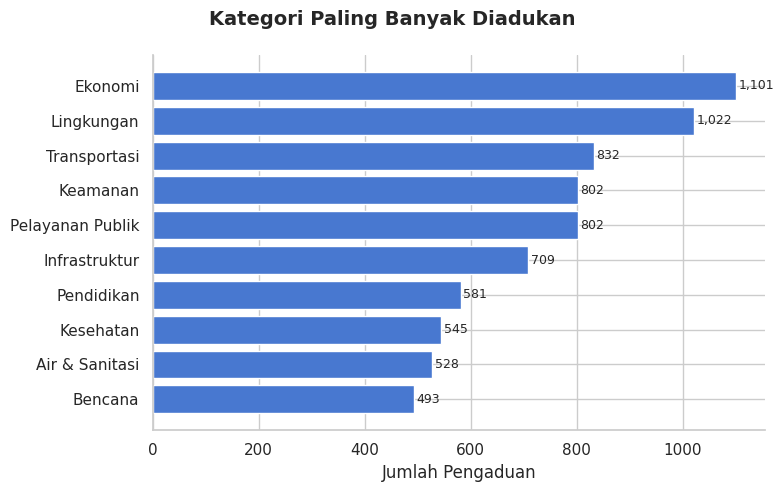

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Kategori Paling Banyak Diadukan", fontsize=14, fontweight="bold")

bars = ax.barh(kategori_count.index, kategori_count.values)

for patch in ax.patches:
    ax.text(
        patch.get_width() + 5,
        patch.get_y() + patch.get_height() / 2,
        f"{int(patch.get_width()):,}",
        va="center", fontsize=9
    )

ax.set_xlabel("Jumlah Pengaduan")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

**Pertanyaan 2**: Kategori apa yang paling banyak memiliki urgensi Tinggi?

In [50]:
df_tinggi = df[df["urgensi"] == "Tinggi"]

tinggi_per_kategori = (
    df_tinggi[kategori_cols]
    .sum()
    .rename(label_map)
    .sort_values(ascending=False)
)

print("=== Kategori dengan Urgensi Tinggi Terbanyak ===")
print(tinggi_per_kategori)

=== Kategori dengan Urgensi Tinggi Terbanyak ===
Bencana             396
Lingkungan          249
Pelayanan Publik    193
Transportasi        159
Pendidikan          140
Infrastruktur       132
Keamanan            122
Air & Sanitasi      117
Kesehatan           111
Ekonomi             107
dtype: int64


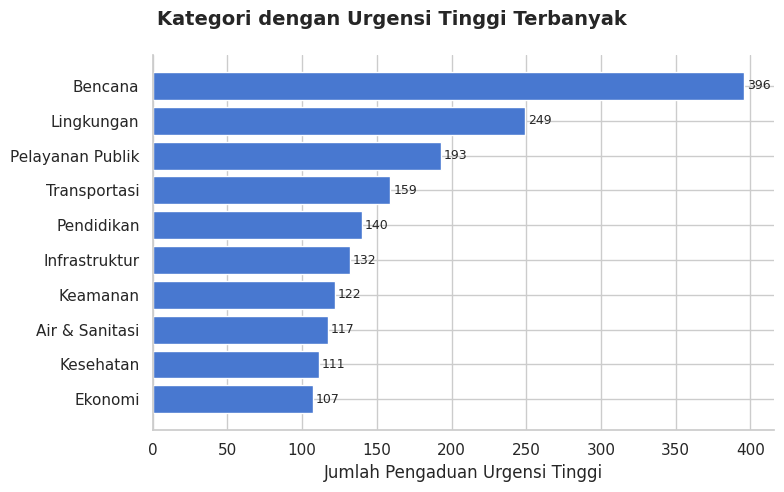

In [55]:
tinggi_plot = tinggi_per_kategori.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Kategori dengan Urgensi Tinggi Terbanyak", fontsize=14, fontweight="bold")

ax.barh(tinggi_plot.index, tinggi_plot.values)

for patch in ax.patches:
    ax.text(
        patch.get_width() + 2,
        patch.get_y() + patch.get_height() / 2,
        f"{int(patch.get_width()):,}",
        va="center", fontsize=9
    )

ax.set_xlabel("Jumlah Pengaduan Urgensi Tinggi")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

**Pertanyaan 3**: Berdasarkan data pengaduan, apakah pengaduan dengan urgensi Tinggi selalu disertai dengan sentimen Negatif? Jika tidak, seberapa besar proporsi urgensi Tinggi yang bersentimen Netral atau Positif sehingga perlu dipertimbangkan dalam pembobotan sentiment intensity pada priority score ADUIN?

In [52]:
sentimen_tinggi = df_tinggi["sentimen"].value_counts()
sentimen_tinggi_pct = (sentimen_tinggi / sentimen_tinggi.sum() * 100).round(2)

print("=== Distribusi Sentimen pada Urgensi Tinggi ===")
print(pd.DataFrame({
    "jumlah": sentimen_tinggi,
    "persen (%)": sentimen_tinggi_pct
}))

negatif_pct  = sentimen_tinggi_pct.get("Negatif", 0)
non_neg_pct  = 100 - negatif_pct

print(f"\nSentimen Negatif  : {negatif_pct:.1f}%")
print(f"Sentimen Non-Negatif : {non_neg_pct:.1f}%")
print(f"  - Netral  : {sentimen_tinggi_pct.get('Netral', 0):.1f}%")
print(f"  - Positif : {sentimen_tinggi_pct.get('Positif', 0):.1f}%")

=== Distribusi Sentimen pada Urgensi Tinggi ===
          jumlah  persen (%)
sentimen                    
Netral      1097       81.50
Negatif      153       11.37
Positif       96        7.13

Sentimen Negatif  : 11.4%
Sentimen Non-Negatif : 88.6%
  - Netral  : 81.5%
  - Positif : 7.1%


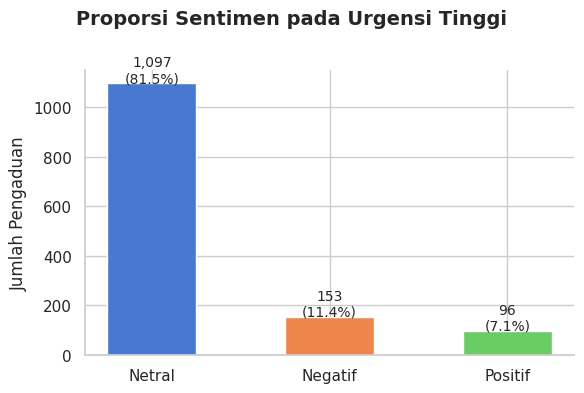

In [56]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle(
    "Proporsi Sentimen pada Urgensi Tinggi",
    fontsize=14, fontweight="bold"
)

for i, (label, jumlah) in enumerate(sentimen_tinggi.items()):
    ax.bar(label, jumlah,  width=0.5)
    ax.text(
        i, jumlah + 5,
        f"{jumlah:,}\n({sentimen_tinggi_pct[label]:.1f}%)",
        ha="center", fontsize=10
    )

ax.set_ylabel("Jumlah Pengaduan")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

Insight:
* **Pertanyaan 1: Kategori apa yang paling banyak diadukan?**
  - Ekonomi (1.101) merupakan kategori yang paling banyak muncul dalam pengaduan, diikuti Lingkungan (1.022) dan Transportasi (832)
  - Sementara Bencana (493) merupakan kategori paling sedikit diadukan, tetapi urgensinya paling tinggi
* **Pertanyaan 2: Kategori apa yang paling banyak memiliki urgensi Tinggi?**
  - Bencana (396) memiliki urgensi Tinggi terbanyak, disusul kategori Lingkungan (249)
  - Sementara, Ekonomi yang jumlah pengaduannya terbanyak justru paling sedikit urgensi Tinggi-nya (107), artinya volume pengaduan tidak berbanding lurus dengan urgensi
  - Hal ini memvalidasi bahwa kategori Bencana meskipun jarang diadukan, hampir selalu dianggap mendesak
* **Pertanyaan 3: Berdasarkan data pengaduan, apakah pengaduan dengan urgensi Tinggi selalu disertai dengan sentimen Negatif? Jika tidak, seberapa besar proporsi urgensi Tinggi yang bersentimen Netral atau Positif sehingga perlu dipertimbangkan dalam pembobotan sentiment intensity pada priority score ADUIN?**
  - Tidak. Urgensi Tinggi justru didominasi sentimen Netral (81.5% atau 1.097 pengaduan)
  - Sentimen Negatif hanya 11.4% (153 pengaduan) dan Positif 7.1% (96 pengaduan)
  - Maknanya, sentimen saja tidak cukup untuk mendeteksi urgensi tinggi. Jika priority score terlalu bergantung pada sentiment intensity, maka 88.6% pengaduan urgensi Tinggi berpotensi mendapat bobot yang lebih rendah dari seharusnya


## Kesimpulan dan Rekomendasi

**Kesimpulan**
- **Conclusion pertanyaan 1:** Ekonomi merupakan kategori yang sering dikeluhkan dibandingkan kategori lainnya (1.101)
- **Conclusion pertanyaan 2:** Bencana merupakan keluhan yang memiliki urgensi Tinggi paling banyak, tetapi tidak paling banyak dikeluhkan (kategori ekonomi mendominasi)
- **Conclusion pertanyaan 3:** Alih-alih sentimen Negatif, urgensi Tinggi justru lebih banyak dikeluhkan dengan sentimen Netral. Artinya, sentimen tidak menjamin urgensi tinggi. Oleh karena itu, perlu adanya kalibrasi untuk pembobotan, jika skor prioritas bergantung pada intensitas sentimen.

**Temuan Batasan Dataset**
- Distribusi kelas tidak seimbang: urgensi Rendah hampir
  3x lipat urgensi Tinggi. Perlu diperhatikan saat training
  model klasifikasi.
- Sentimen Netral sangat dominan (79.7%) — model sentimen
  yang digunakan kemungkinan konservatif dalam melabeli
  Negatif.
- Sebanyak 46 teks sangat pendek (<5 kata), bersumber dari Twitter. Hal yang normal karena Twitter memiliki bahasa yang tidak baku dan penulisan yang singkat-singkat

**Recommendation Action Item**
- Dapat dilihat ketidakseimbangan antarkategori dalam evaluasi model, kategori dengan jumlah pengaduan sedikit, tetapi proporsi urgensi Tinggi yang besar, seperti Bencana berpotensi diabaikan oleh model. Hal ini bisa diatasi menggunakan F1-score untuk evaluasi tiap kelasnya